In [1]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgbb
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score, matthews_corrcoef,cohen_kappa_score, recall_score, precision_score
from sklearn.naive_bayes import GaussianNB
import math as mt
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight
# Data Visualization
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns
from sklearn.utils import class_weight
import warnings
warnings.filterwarnings('ignore')

# For Uni - Variate Analysis
from sklearn.feature_selection import VarianceThreshold
# Other Libraries
import os
import io
import requests
from sklearn.preprocessing import StandardScaler

from pyod.models.iforest import IForest

from pyod.models.deep_svdd import DeepSVDD
from imblearn.over_sampling import SMOTE


from sklearn.feature_selection import RFE, SelectKBest, f_classif, chi2
from sklearn.linear_model import Lasso

from boruta import BorutaPy
from scipy.stats import spearmanr, kendalltau
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mtick

In [2]:
# Import Dataset

df1=pd.read_csv(r"C:\Users\abhii\lung-main\project_lung.csv")
# Note


In [3]:
df1

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [5]:
df1.isna().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [7]:
le = LabelEncoder()
for col in df1.columns:
    if df1[col].dtype=='object':
        df1[col]=le.fit_transform(df1[col])

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    int64
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 non-null    i

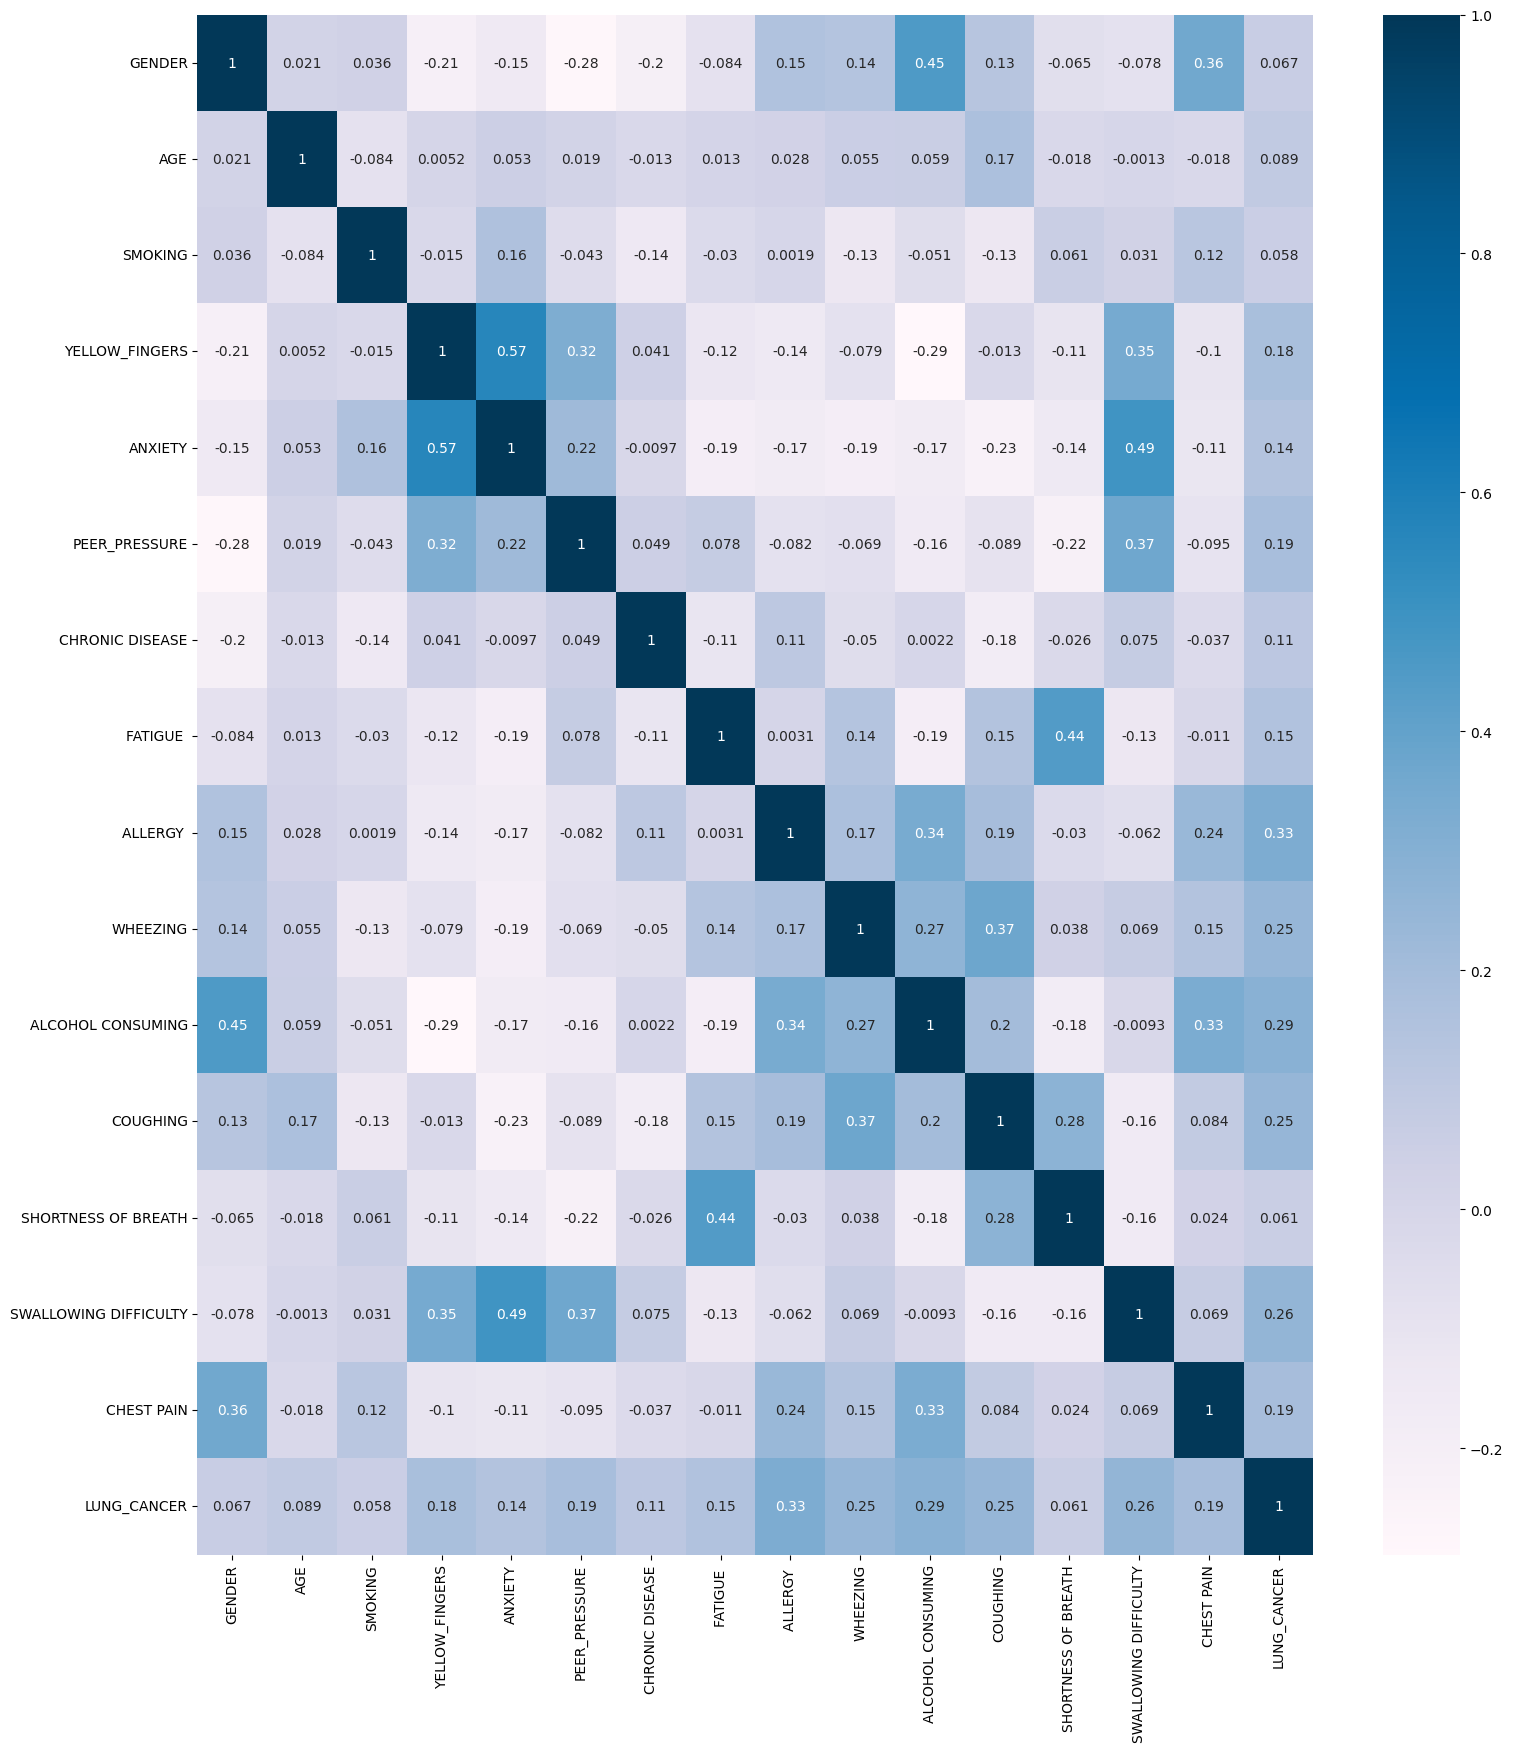

In [9]:
plt.figure(figsize=(18,20))
dataplot = sns.heatmap(df1.corr(), cmap="PuBu", annot=True)
plt.show()

In [10]:
df1.rename(columns={'LUNG_CANCER': 'TARGET'}, inplace=True)

In [11]:
df1["TARGET"].describe()

count    309.000000
mean       0.873786
std        0.332629
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: TARGET, dtype: float64

In [12]:
df1.TARGET.value_counts() / len(df1) * 100

TARGET
1    87.378641
0    12.621359
Name: count, dtype: float64

In [13]:
# Duplicate Values

df1.TARGET.value_counts() 

TARGET
1    270
0     39
Name: count, dtype: int64

<Axes: ylabel='count'>

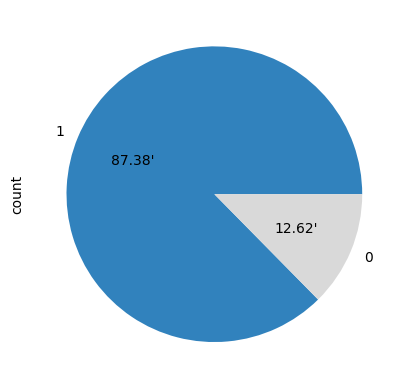

In [14]:
df1["TARGET"].value_counts().plot(kind="pie", autopct ="%.2f'", cmap= 'tab20c')

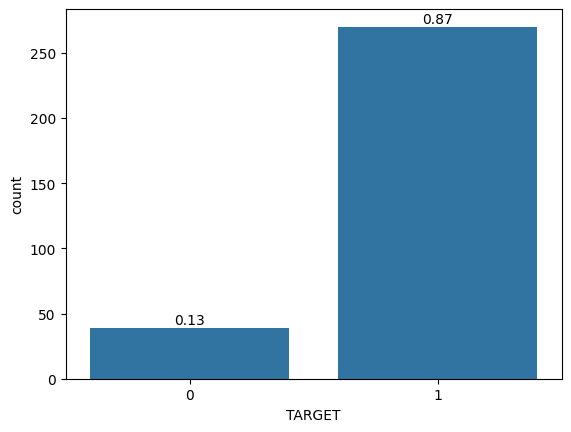

In [15]:
total = float(len(df1)) # one person per row

ax = sns.countplot(x = "TARGET", data = df1)        
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")

In [16]:
df1.duplicated().sum()

np.int64(33)

In [17]:
df1.drop('GENDER', axis=1 , inplace=True)
df1.shape

(309, 15)

In [18]:
df1.drop('AGE', axis=1 , inplace=True)
df1.shape

(309, 14)

In [19]:
cor_target = df1.corrwith(df1["TARGET"])

cor_target

SMOKING                  0.058179
YELLOW_FINGERS           0.181339
ANXIETY                  0.144947
PEER_PRESSURE            0.186388
CHRONIC DISEASE          0.110891
FATIGUE                  0.150673
ALLERGY                  0.327766
WHEEZING                 0.249300
ALCOHOL CONSUMING        0.288533
COUGHING                 0.248570
SHORTNESS OF BREATH      0.060738
SWALLOWING DIFFICULTY    0.259730
CHEST PAIN               0.190451
TARGET                   1.000000
dtype: float64

In [20]:
cor_target.sort_values(axis = 0, ascending = False)

TARGET                   1.000000
ALLERGY                  0.327766
ALCOHOL CONSUMING        0.288533
SWALLOWING DIFFICULTY    0.259730
WHEEZING                 0.249300
COUGHING                 0.248570
CHEST PAIN               0.190451
PEER_PRESSURE            0.186388
YELLOW_FINGERS           0.181339
FATIGUE                  0.150673
ANXIETY                  0.144947
CHRONIC DISEASE          0.110891
SHORTNESS OF BREATH      0.060738
SMOKING                  0.058179
dtype: float64

In [21]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   SMOKING                309 non-null    int64
 1   YELLOW_FINGERS         309 non-null    int64
 2   ANXIETY                309 non-null    int64
 3   PEER_PRESSURE          309 non-null    int64
 4   CHRONIC DISEASE        309 non-null    int64
 5   FATIGUE                309 non-null    int64
 6   ALLERGY                309 non-null    int64
 7   WHEEZING               309 non-null    int64
 8   ALCOHOL CONSUMING      309 non-null    int64
 9   COUGHING               309 non-null    int64
 10  SHORTNESS OF BREATH    309 non-null    int64
 11  SWALLOWING DIFFICULTY  309 non-null    int64
 12  CHEST PAIN             309 non-null    int64
 13  TARGET                 309 non-null    int64
dtypes: int64(14)
memory usage: 33.9 KB


In [22]:
# Duplicate Values

df1.duplicated().sum()

np.int64(176)

In [23]:
df1=df1.drop_duplicates()
df1.duplicated().sum()

np.int64(0)

In [24]:
df1

,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,TARGET
0,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,1,2,1,1,1,1,1,2,1,2,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,2,2,2,1,2,1,2,2,1,1,1,2,2,1
243,1,1,2,1,2,2,1,2,2,2,2,2,1,1
245,1,1,1,2,1,2,1,2,1,1,2,1,2,0
252,1,2,2,2,2,1,2,1,2,1,1,2,2,1


In [25]:

# Assuming 'your_dataframe' is your DataFrame
df1 = df1.sample(frac=1, random_state=42)
df5 = df1.sample(n=133, random_state=42)
# Reset the index of the shuffled DataFrame
df5.reset_index(drop=True, inplace=True)
df5

,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,TARGET
0,2,1,1,1,2,2,1,1,1,1,2,1,1,1
1,2,2,2,2,2,1,1,1,1,1,1,1,1,1
2,2,2,2,1,2,2,2,2,2,2,2,1,1,1
3,2,1,1,1,2,2,2,1,1,1,2,1,1,0
4,1,2,2,2,2,2,2,1,1,2,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,2,1,1,2,1,1,1,1,1,1,1,1,2,0
129,2,1,1,1,1,1,2,2,2,2,1,1,2,1
130,2,2,2,2,1,2,1,2,1,2,2,2,1,1
131,1,1,2,1,1,2,1,2,2,2,2,2,1,1


In [26]:
print(df5.TARGET.value_counts())

TARGET
1    109
0     24
Name: count, dtype: int64


<Axes: ylabel='count'>

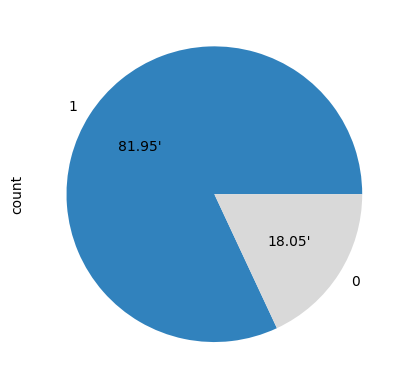

In [27]:
df5["TARGET"].value_counts().plot(kind="pie", autopct ="%.2f'", cmap= 'tab20c')

In [28]:
df6=df5.copy()

In [29]:
# Segregating Target Variable from Predictors

df_x = df5.drop(labels = ["TARGET"], axis = 1) 
df_y = df5[["TARGET"]]

In [30]:
# Train Isolation Forest model
isolation_forest = IForest(contamination=0.2, random_state=42)  # Adjust contamination as needed
isolation_forest.fit(df_x)

# Predict outliers
outlier_preds = isolation_forest.predict(df_x)

# Identify inliers (samples with label 1)
inliers_mask = outlier_preds == 0
X_inliers = df_x[inliers_mask]


df_y = df5[["TARGET"]] 
y_inliers = df_y[inliers_mask]

In [31]:
outlier_preds

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0])

In [32]:
inliers_mask

array([ True,  True,  True,  True,  True, False, False,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True,  True,  True, False, False,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True, False, False, False,  True,
        True,  True,  True, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True, False, False, False,  True,  True,  True,
        True,  True, False, False,  True,  True,  True,  True, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True, False,  True,
        True,  True,

In [33]:
X_inliers

,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,2,1,1,1,2,2,1,1,1,1,2,1,1
1,2,2,2,2,2,1,1,1,1,1,1,1,1
2,2,2,2,1,2,2,2,2,2,2,2,1,1
3,2,1,1,1,2,2,2,1,1,1,2,1,1
4,1,2,2,2,2,2,2,1,1,2,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,2,1,1,2,1,1,1,1,1,1,1,1,2
129,2,1,1,1,1,1,2,2,2,2,1,1,2
130,2,2,2,2,1,2,1,2,1,2,2,2,1
131,1,1,2,1,1,2,1,2,2,2,2,2,1


In [34]:
X_inliers.reset_index(drop=True, inplace=True)
y_inliers.reset_index(drop=True, inplace=True)

In [35]:
# Split data into features and target variable
df_x = X_inliers.copy()
y = y_inliers.copy()

# Feature scaling
scaler = StandardScaler()
X1 = scaler.fit_transform(df_x)

dfx=pd.DataFrame(X1,columns=df_x.columns)

In [36]:
# Split data into training and testing sets
X_train_scaled , X_test_scaled , y_train, y_test = train_test_split(dfx, y, test_size=0.2, random_state=42)

In [37]:
df_y

,TARGET
0,1
1,1
2,1
3,0
4,1
...,...
128,0
129,1
130,1
131,1


In [38]:
from imblearn.combine import SMOTEENN
smote = SMOTEENN()
df_x_resampled,df_y_resampled = smote.fit_resample(df_x,y)

In [39]:
print(df_x.shape)
print(df_y.shape)

(106, 13)
(133, 1)


In [40]:
print(df_x.shape)
print(y.shape)

(106, 13)
(106, 1)


In [41]:
df_x_resampled.shape

(114, 13)

In [42]:
df_y_resampled.shape

(114, 1)

In [43]:
df_y_resampled.value_counts()

TARGET
0         58
1         56
Name: count, dtype: int64

In [44]:
X_train_scaled.reset_index(drop=True, inplace=True)
X_test_scaled.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [45]:
# Recursive Feature Elimination (RFE) with RandomForestClassifier
def rfe_feature_selection(X_train, X_test, y_train):
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    best_accuracy = 0
    best_num_features = 0
    best_selected_features=[]
    # Iterate over different numbers of features
    for num_features in range(1, X_train.shape[1] + 1):
        # Initialize RFE
        rfe = RFE(estimator=rf, n_features_to_select=num_features, step=1)
    
        # Fit RFE
        rfe.fit(X_train, y_train)
        
        # Get selected features
        selected_features = X_train.columns[rfe.support_]
    
        # Transform datasets
        X_train_rfe = rfe.transform(X_train)
        X_test_rfe = rfe.transform(X_test)
    
        # Train RandomForestClassifier with selected features
        rf.fit(X_train_rfe, y_train)
    
        # Predict
        y_pred = rf.predict(X_test_rfe)
    
        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
    
        # Update best accuracy and number of features if current accuracy is higher
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_num_features = num_features
            best_selected_features = selected_features


    print("Best number of features:", best_num_features)
    print("Best selected features:", best_selected_features)
    print("Highest accuracy:", best_accuracy)
    return X_train_rfe, X_test_rfe, best_selected_features

In [46]:
# Forward Feature Selection
def forward_feature_selection(X_train, X_test, y_train, model):
    selected_features = []
    best_accuracy = 0
    while len(selected_features) < X_train.shape[1]:
        for feature in X_train.columns:
            if feature not in selected_features:
                temp_features = selected_features + [feature]
                model.fit(X_train[temp_features], y_train)
                accuracy = model.score(X_test[temp_features], y_test)
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_feature = feature
        selected_features.append(best_feature)
    print("Best selected features:", selected_features)
    print("Best accuracy:", best_accuracy)
    return X_train[selected_features], X_test[selected_features], selected_features

In [47]:
# Forward Feature Selection
def forward_feature_selection11(X_train, X_test, y_train, y_test, model):
    selected_features = []
    best_accuracy = 0
    while len(selected_features) < X_train.shape[1]:
        best_accuracy_for_iteration = 0
        best_feature_for_iteration = None
        for feature in X_train.columns:
            if feature not in selected_features:
                temp_features = selected_features + [feature]
                model.fit(X_train[temp_features], y_train)
                accuracy = model.score(X_test[temp_features], y_test)
                if accuracy > best_accuracy_for_iteration:
                    best_accuracy_for_iteration = accuracy
                    best_feature_for_iteration = feature
        selected_features.append(best_feature_for_iteration)
        if best_accuracy_for_iteration > best_accuracy:
            best_accuracy = best_accuracy_for_iteration
    print("Best selected features:", selected_features)
    print("Best accuracy:", best_accuracy)
    return X_train[selected_features], X_test[selected_features], selected_features


In [48]:
# Backward Feature Selection
def backward_feature_selection(X_train, X_test, y_train, model):
    selected_features = list(X_train.columns)
    best_accuracy = model.fit(X_train, y_train).score(X_test, y_test)  # Initial accuracy with all features
    while len(selected_features) > 0:
        best_feature = None
        for feature in selected_features:
            temp_features = selected_features.copy()
            temp_features.remove(feature)
            accuracy = model.fit(X_train[temp_features], y_train).score(X_test[temp_features], y_test)
            if accuracy >= best_accuracy:  # Adjusted condition
                best_accuracy = accuracy
                best_feature = feature
        if best_feature is not None:
            selected_features.remove(best_feature)
        else:
            break  # Exit the loop if no improvement is found
    print("Best selected features:", selected_features)
    print("Best accuracy:", best_accuracy)
    return X_train[selected_features], X_test[selected_features], selected_features

In [49]:
# ANOVA F-value
def anova_f_value_selection11(X_train, X_test, y_train, y_test, k):
    skb = SelectKBest(score_func=f_classif, k=k)
    X_train_skb = skb.fit_transform(X_train, y_train)
    X_test_skb = skb.transform(X_test)
    return X_train_skb, X_test_skb, skb.get_support()

In [50]:
# Pearson Correlation
def pearson_correlation_selection(X_train, X_test, threshold):
    corr_matrix = X_train.corr()
    corr_features = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                corr_features.add(colname)
    X_train_corr = X_train.drop(labels=corr_features, axis=1)
    X_test_corr = X_test.drop(labels=corr_features, axis=1)
    return X_train_corr, X_test_corr

In [51]:
def lasso_regression_feature_selection(X_train, X_test, y_train, y_test, alpha):
    # Initialize Lasso regression model
    lasso = Lasso(alpha=alpha, random_state=42)
    
    # Fit Lasso regression on training data
    lasso.fit(X_train, y_train)
    
    # Get coefficients and select features with non-zero coefficients
    selected_features = X_train.columns[lasso.coef_ != 0]
    
    # Train RandomForestClassifier with selected features
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_classifier.fit(X_train[selected_features], y_train)
    
    # Predict
    y_pred = rf_classifier.predict(X_test[selected_features])
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    print("Selected features with Lasso regression:", selected_features)
    #print("Accuracy with selected features:", accuracy)
    
    return X_train[selected_features], X_test[selected_features], selected_features


In [52]:
np.int = np.int32
np.float = np.float64
np.bool = np.bool_

In [53]:
# Boruta method
def boruta_feature_selection(X_train, X_test, y_train, y_test):
    # Initialize BorutaPy object with RandomForestClassifier estimator
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    boruta_selector = BorutaPy(rf, n_estimators='auto', random_state=42)
    
    # Fit Boruta on training data
    boruta_selector.fit(X_train.values, y_train.values)
    
    # Get selected features
    selected_features = X_train.columns[boruta_selector.support_].tolist()
    
    # Train a model using selected features
    rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_selected.fit(X_train[selected_features], y_train)
    
    # Predict on testing data
    y_pred = rf_selected.predict(X_test[selected_features])
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    #print("Selected features with Boruta:", selected_features)
    #print("Accuracy with selected features:", accuracy)
    
    return X_train[selected_features], X_test[selected_features], selected_features

In [54]:
# Apply feature selection methods
X_train_rfe, X_test_rfe, rfe_fs = rfe_feature_selection(X_train_scaled, X_test_scaled, y_train)
X_train_forward, X_test_forward, forward_fs = forward_feature_selection11(X_train_scaled, X_test_scaled, y_train, y_test, RandomForestClassifier())
X_train_backward, X_test_backward, backward_fs = backward_feature_selection(X_train_scaled, X_test_scaled, y_train, RandomForestClassifier())
X_train_lasso, X_test_lasso, lasso_fs = lasso_regression_feature_selection(X_train_scaled, X_test_scaled, y_train, y_test, alpha=0.01)
X_train_boruta, X_test_boruta, boruta_fs =boruta_feature_selection(X_train_scaled, X_test_scaled, y_train, y_test)

Best number of features: 3
Best selected features: Index(['ANXIETY', 'CHRONIC DISEASE', 'ALCOHOL CONSUMING'], dtype='object')
Highest accuracy: 0.8181818181818182
Best selected features: ['SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'CHRONIC DISEASE', 'FATIGUE ', 'PEER_PRESSURE', 'ALCOHOL CONSUMING', 'WHEEZING', 'ALLERGY ', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN']
Best accuracy: 0.8636363636363636
Best selected features: ['CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ']
Best accuracy: 0.9545454545454546
Selected features with Lasso regression: Index(['SMOKING', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ',
       'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN'],
      dtype='object')


In [55]:
# Initialize RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

best_accuracy = 0
best_selected_features = []

# Iterate over different numbers of features
for num_features in range(1, X_train_scaled.shape[1] + 1):
    # Apply ANOVA F-value selection
    X_train_skb, X_test_skb, selected_features = anova_f_value_selection11(X_train_scaled, X_test_scaled, y_train, y_test, num_features)
    
    # Train RandomForestClassifier with selected features
    rf_classifier.fit(X_train_skb, y_train)
    
    # Predict
    y_pred = rf_classifier.predict(X_test_skb)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Update best accuracy and selected features if current accuracy is higher
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_selected_features = selected_features

print("Features with highest accuracy:", best_selected_features)
#print("Highest accuracy:", best_accuracy)

df_selected = X_train_scaled.loc[:, best_selected_features]
print(df_selected.columns)
anv_fs=df_selected.columns
X_train_skb, X_test_skb=X_train_scaled[df_selected.columns],X_test_scaled[df_selected.columns]

Features with highest accuracy: [False False  True False  True False  True False  True False False  True
 False]
Index(['ANXIETY', 'CHRONIC DISEASE', 'ALLERGY ', 'ALCOHOL CONSUMING',
       'SWALLOWING DIFFICULTY'],
      dtype='object')


In [56]:
X_train_corr, X_test_corr = pearson_correlation_selection(X_train_scaled, X_test_scaled, threshold=0.5)
pcorr_fs=X_train_corr.columns

In [57]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

lr_train_mae = mean_absolute_error(y_train, lr_train_preds)
lr_test_mae = mean_absolute_error(y_test, lr_test_preds)

result = permutation_importance(lr, X_train_scaled, y_train, n_repeats=3)
lr_fi = result.importances_mean

print(lr_fi)

NameError: name 'lr_train_preds' is not defined

In [ ]:
# Sort feature importances in descending order
sorted_indices = np.argsort(lr_fi)[::-1]

# Get the names of features corresponding to the sorted importances
sorted_features = X_train_scaled.columns[sorted_indices]

# Get the top 5 features
lr_features = sorted_features[:7]

print("Top 7 features:", lr_features)

In [ ]:
# KNN
knn = KNeighborsRegressor(n_neighbors=int(np.sqrt(len(X_train_scaled))))
knn.fit(X_train_scaled, y_train)

knn_train_preds = knn.predict(X_train_scaled)
knn_test_preds = knn.predict(X_test_scaled)

knn_train_mae = mean_absolute_error(y_train, knn_train_preds)
knn_test_mae = mean_absolute_error(y_test, knn_test_preds)

from sklearn.inspection import permutation_importance

result = permutation_importance(knn, X_train_scaled, y_train, n_repeats=3)
knn_fi = result.importances_mean

print(knn_fi)

In [ ]:
# Sort feature importances in descending order
sorted_indices = np.argsort(knn_fi)[::-1]

# Get the names of features corresponding to the sorted importances
sorted_features = X_train_scaled.columns[sorted_indices]

# Get the top 5 features
knn_features = sorted_features[:7]

print("Top 7 features:", knn_features)

In [ ]:
# Support Vector Regression
svr = SVR(C=.1)
svr.fit(X_train_scaled, y_train)

svr_train_preds = svr.predict(X_train_scaled)
svr_test_preds = svr.predict(X_test_scaled)

svr_train_mae = mean_absolute_error(y_train, svr_train_preds)
svr_test_mae = mean_absolute_error(y_test, svr_test_preds)

from sklearn.inspection import permutation_importance

result = permutation_importance(svr, X_train_scaled, y_train, n_repeats=3)
svr_fi = result.importances_mean

print(svr_fi)

In [ ]:
# Sort feature importances in descending order
sorted_indices = np.argsort(svr_fi)[::-1]

# Get the names of features corresponding to the sorted importances
sorted_features = X_train_scaled.columns[sorted_indices]

# Get the top 5 features
svm_features = sorted_features[:7]

print("Top 7 features:", svm_features)

In [ ]:
# Random Forest
rf = RandomForestRegressor(max_depth=7)
rf.fit(X_train_scaled, y_train)

rf_train_preds = rf.predict(X_train_scaled)
rf_test_preds = rf.predict(X_test_scaled)

rf_train_mae = mean_absolute_error(y_train, rf_train_preds)
rf_test_mae = mean_absolute_error(y_test, rf_test_preds)

rf_fi = rf.feature_importances_
rf_fi

In [ ]:
# Sort feature importances in descending order
sorted_indices = np.argsort(rf_fi)[::-1]

# Get the names of features corresponding to the sorted importances
sorted_features = X_train_scaled.columns[sorted_indices]

# Get the top 5 features
rf_features = sorted_features[:7]

print("Top 7 features:", rf_features)

In [ ]:
# XGBOOST
xgb = XGBRegressor(max_depth=7)
xgb.fit(X_train_scaled, y_train)

xgb_train_preds = xgb.predict(X_train_scaled)
xgb_test_preds = xgb.predict(X_test_scaled)

xgb_train_mae = mean_absolute_error(y_train, xgb_train_preds)
xgb_test_mae = mean_absolute_error(y_test, xgb_test_preds)

xgb_fi = xgb.feature_importances_
xgb_fi

In [ ]:
# Sort feature importances in descending order
sorted_indices = np.argsort(xgb_fi)[::-1]

# Get the names of features corresponding to the sorted importances
sorted_features = X_train_scaled.columns[sorted_indices]

# Get the top 5 features
xgb_features = sorted_features[:7]

print("Top 7 features:", xgb_features)

In [ ]:
# Light GBM
lgb = LGBMRegressor(max_depth=7)
lgb.fit(X_train_scaled, y_train)

lgb_train_preds = lgb.predict(X_train_scaled)
lgb_test_preds = lgb.predict(X_test_scaled)

lgb_train_mae = mean_absolute_error(y_train, lgb_train_preds)
lgb_test_mae = mean_absolute_error(y_test, lgb_test_preds)

lgb_fi = lgb.feature_importances_
lgb_fi

In [ ]:
# Sort feature importances in descending order
sorted_indices = np.argsort(lgb_fi)[::-1]

# Get the names of features corresponding to the sorted importances
sorted_features = X_train_scaled.columns[sorted_indices]

# Get the top 5 features
lgb_features = sorted_features[:7]

print("Top 7 features:", lgb_features)

In [ ]:
# create a dataframe for feature importances and mean absolute error
mae_df = pd.DataFrame(columns=['Train','Test'])

# add mae's to the mae_df
mae_df.loc['Linear Regression','Train'] =  lr_train_mae
mae_df.loc['Linear Regression','Test'] =  lr_test_mae

mae_df.loc['KNN','Train'] =  knn_train_mae
mae_df.loc['KNN','Test'] =  knn_test_mae

mae_df.loc['Support Vector Regression','Train'] =  svr_train_mae
mae_df.loc['Support Vector Regression','Test'] =  svr_test_mae

mae_df.loc['Random Forest','Train'] =  rf_train_mae
mae_df.loc['Random Forest','Test'] =  rf_test_mae

mae_df.loc['XGBoost','Train'] =  xgb_train_mae
mae_df.loc['XGBoost','Test'] =  xgb_test_mae

mae_df.loc['Light GBM','Train'] =  lgb_train_mae
mae_df.loc['Light GBM','Test'] =  lgb_test_mae

mae_df['Model'] = mae_df.index
mae_df['Train'] = mae_df['Train'].astype(float)
mae_df['Test'] = mae_df['Test'].astype(float)

mae_df = pd.melt(mae_df, id_vars=['Model'], value_vars=['Train','Test'])

In [ ]:
# plot mae
fig,ax = plt.subplots(figsize=(10,4))
ax = sns.barplot(x='value',y='Model', hue='variable',data=mae_df.sort_values(by='value',ascending=False))
plt.xlabel('Mean Absolute Error')
plt.ylabel('')
plt.title('Mean Absolute Error Comparison')
plt.tight_layout()

In [ ]:
# create feature importance dataframe
fi_df = pd.DataFrame(columns=['LR', 'KNN','SVR','RF','XGB','LGBM','Features'])
#feature_names =    ["a", "b", "c", "d","e", "f", "g", "h","i", "j", "k", "l","m", "n", "o"]

fi_df['Features'] = dfx.columns
fi_df['LR'] = lr_fi
fi_df['KNN'] = knn_fi
fi_df['SVR'] = svr_fi
fi_df['RF'] = rf_fi
fi_df['XGB'] = xgb_fi
fi_df['LGBM'] = lgb_fi/1000

In [ ]:
fi_df

In [ ]:
fig = plt.figure(figsize=(18,8))

plt.subplot(2, 3, 1)
ax = sns.barplot(x='LR',y='Features',data=fi_df.sort_values(by='LR',ascending=False),color='b')
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('Linear Regression')
plt.axvline(x=0.1, color='r', linestyle='dashed')
plt.tight_layout()

plt.subplot(2, 3, 2)
ax = sns.barplot(x='KNN',y='Features',data=fi_df.sort_values(by='KNN',ascending=False),color='b')
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('K-Nearest Neighbors')
plt.axvline(x=0.1, color='r', linestyle='dashed')
plt.tight_layout()

plt.subplot(2, 3, 3)
ax = sns.barplot(x='SVR',y='Features',data=fi_df.sort_values(by='SVR',ascending=False),color='b')
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('Support Vector Regression')
plt.axvline(x=0.1, color='r', linestyle='dashed')
plt.tight_layout()

plt.subplot(2, 3, 4)
ax = sns.barplot(x='RF',y='Features',data=fi_df.sort_values(by='RF',ascending=False),color='b')
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('Random Forest')
plt.axvline(x=0.1, color='r', linestyle='dashed')
plt.tight_layout()

plt.subplot(2, 3, 5)
ax = sns.barplot(x='XGB',y='Features',data=fi_df.sort_values(by='XGB',ascending=False),color='b')
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('XGBoost')
plt.axvline(x=0.1, color='r', linestyle='dashed')
plt.tight_layout()

plt.subplot(2, 3, 6)
ax = sns.barplot(x='LGBM',y='Features',data=fi_df.sort_values(by='LGBM',ascending=False),color='b')
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('Light GBM')
plt.axvline(x=0.1, color='r', linestyle='dashed')
plt.tight_layout()

In [ ]:
from boruta import BorutaPy

new_rf = RandomForestRegressor(n_jobs = -1, max_depth = 5)

boruta_selector = BorutaPy(new_rf, n_estimators = 'auto', random_state = 0)
boruta_selector.fit(np.array(X_train_scaled), np.array(y_train))

boruta_ranking = boruta_selector.ranking_
boruta_features = np.array(dfx.columns)[boruta_ranking <= 3]

In [ ]:
boruta_ranking = pd.DataFrame(data=boruta_ranking, index=X_train_scaled.columns.values, columns=['values'])
boruta_ranking['Variable'] = boruta_ranking.index
boruta_ranking.sort_values(['values'], ascending=True, inplace=True)

In [ ]:
fig,ax = plt.subplots(figsize=(8,4))
ax = sns.barplot(x='values',y='Variable',data=boruta_ranking, color='b')
plt.title('Boruta Feature Ranking')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()

In [ ]:
feature_names =dfx.columns

In [ ]:
# Convert array to list
feature_list = boruta_features.tolist()
#feature_list

In [ ]:
from collections import Counter

# Lists of features
LRf = lr_features.tolist()
KNNf= knn_features.tolist()
SVRf= svm_features.tolist()
RFf= rf_features.tolist()
XGBf= xgb_features.tolist()
LGBMf=lgb_features.tolist()
BORf=boruta_features.tolist()

# Combine all lists
all_features = LRf + KNNf + SVRf + RFf + XGBf + LGBMf + BORf
Uf=list(set().union(LRf,KNNf,SVRf,RFf,XGBf,LGBMf,BORf))
# Count occurrences of each feature
feature_counts = Counter(all_features)

# Find the features with the highest counts
majority_features = [feature for feature, count in feature_counts.items() if count > 3]  # Adjust threshold as needed
#print("All features:", Uf)
print("Majority features:", majority_features)

In [ ]:
def evall(Xf,yf,fs,sm):
    t=0
    data=[]
    
    # Perform StratifiedKFold cross-validation
    cv = StratifiedKFold(n_splits=10)
    weights1 = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(yf),
    y=yf.values.reshape(-1))
    print("weights = ",weights1)
    a=weights1[0]
    b=weights1[1]

    lr = LogisticRegression(random_state=42, class_weight={0: a, 1: b})
    svm = SVC()
    knn = KNeighborsClassifier()
    dt = DecisionTreeClassifier()
    ab = AdaBoostClassifier()
    gb = GradientBoostingClassifier()
    lgbm = lgbb.LGBMClassifier(verbose=-1)
    cb = CatBoostClassifier(verbose=0)
    et = ExtraTreesClassifier()
    rf= RandomForestClassifier()
    xgb = XGBClassifier()
    gnb = GaussianNB()


    clff=[lr, svm, knn, dt, ab, gb, lgbm, cb, et, rf, xgb, gnb]
    cl=['lr','svm','knn','dt','ab','gb','lgbm','cb','et','rf','xgb','gnb']
    
    for clf in clff:
        accuracies4 = []
        spec4=[]
        mcc4=[]
        ck4=[]
        f14=[]
        pr4=[]
        re4=[]
        gmean4=[]
        r4=[]
        for train_index, test_index in cv.split(Xf, yf):
            X_traincv, X_testcv = Xf.iloc[train_index], Xf.iloc[test_index]
            y_traincv, y_testcv = yf.iloc[train_index], yf.iloc[test_index]
      
            clf.fit(X_traincv, y_traincv)
            y_pred1 = clf.predict(X_testcv)
            
            accuracy1 = accuracy_score(y_testcv, y_pred1)
            accuracies4.append(accuracy1)
            
            clf_report = pd.DataFrame(classification_report(y_testcv, y_pred1, output_dict=True))
            cm = confusion_matrix(y_testcv, y_pred1)
            tn = cm[0][0]
            fn = cm[1][0]
            fp = cm[0][1]
            tp = cm[1][1]
            
            sp = tn/(tn+fp)
            spec4.append(sp)
            
            Pre = precision_score(y_testcv, y_pred1)
            pr4.append(Pre)
            
            Rec=recall_score(y_testcv, y_pred1)
            re4.append(Rec)
            
            gm=mt.sqrt(sp*Rec)
            gmean4.append(gm)
            
            m=matthews_corrcoef(y_testcv, y_pred1)
            mcc4.append(m)
            
            c=cohen_kappa_score(y_testcv, y_pred1)
            ck4.append(c)
            
            f=f1_score(y_testcv, y_pred1)
            f14.append(f)
            
            roc=roc_auc_score(y_testcv, y_pred1)
            r4.append(roc)
            
        average_accuracy4 = sum(accuracies4) / len(accuracies4)
        average_specificity4 = sum(spec4) / len(spec4)
        average_mcc4 = sum(mcc4) / len(mcc4)
        average_ck4 = sum(ck4) / len(ck4)
        average_f14 = sum(f14) / len(f14)
        average_Precision4 = sum(pr4) / len(pr4)
        average_Recall4 = sum(re4) / len(re4)
        average_gmean4 = sum(gmean4) / len(gmean4)
        average_roc4 = sum(r4) / len(r4)

        #data.append((clff[t],f"{average_accuracy4:{w}.{pre}}",f"{average_specificity4:{w}.{pre}}",f"{average_mcc4:{w}.{pre}}",f"{average_ck4:{w}.{pre}}",f"{average_f14:{w}.{pre}}",f"{average_Precision4:{w}.{pre}}",f"{average_Recall4:{w}.{pre}}",f"{average_gmean4:{w}.{pre}}",f"{average_roc4:{w}.{pre}}"))
        data.append((fs,sm,cl[t],average_accuracy4,average_specificity4,average_mcc4,average_ck4,average_f14,average_Precision4,average_Recall4,average_gmean4,average_roc4))

        t=t+1
    return data

In [ ]:
def favg(df):
    selected_columns = ['Accuracy','Specificity','MCC','CK','F1-Score','Precision','Recall','Gmean','roc_Score']
    row_averages = df[selected_columns].mean(axis=1)
    df['Pmean'] = row_averages
    print(df.to_string(index=False,justify='left'))
    return df

In [ ]:
def evgraph(df):
    
    # Transpose the DataFrame
    selected_columns = ['Classifier','Accuracy','Specificity','MCC','CK','F1-Score','Precision','Recall','Gmean','roc_Score','Pmean']
    df1 = df[selected_columns]
    dfr_transposed = df1.set_index('Classifier').T.reset_index()
    # Plotting the multi-line graph with transposed data
    plt.figure(figsize=(8, 6))

    classifiers = dfr_transposed.columns[1:]  # Exclude the 'index' column

    for classifier in classifiers:
        plt.plot(dfr_transposed['index'], dfr_transposed[classifier], marker='o', linestyle='-', label=classifier)

    # Adding labels and title
    plt.xlabel('Metrics')
    plt.ylabel('Classifier Values')
    plt.title('Classifiers Across Metrics')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility

    # Adding a legend
    plt.legend()
    # Adding horizontal grid lines
    plt.grid(True, axis='y')
    # Display the plot
    plt.tight_layout()
    plt.show()

In [ ]:
fdf=dfx.copy()
fdf['TARGET']=y
fdf

In [ ]:
RFEf=rfe_fs.tolist()
FORWf=forward_fs
BACKWf=backward_fs
ANOf=anv_fs.tolist()
PEARf=pcorr_fs.tolist()
LASSOf=lasso_fs.tolist()

In [ ]:
odresult=[]
fsname=['LRf' , 'KNNf' , 'SVRf' , 'RFf', 'XGBf', 'LGBMf', 'BORf', 'RFEf', 'FORWf', 'BACKWf', 'ANOf', 'PEARf', 'LASSOf', 'Uf', 'majority_features']

lt=[LRf , KNNf , SVRf , RFf, XGBf, LGBMf, BORf, RFEf, FORWf, BACKWf, ANOf, PEARf, LASSOf, Uf, majority_features]
#lt

tin=0



In [ ]:
for i in lt:
    d_x = fdf[i]
    #print(d_x)
    dfy = fdf[["TARGET"]]
    dt=evall(d_x,y,fsname[tin],0)
    odresult.extend(dt)
    dfout=pd.DataFrame(dt,columns=['FName','SMOTE','Classifier','Accuracy','Specificity','MCC','CK','F1-Score','Precision','Recall','Gmean','roc_Score'])
    dfout=favg(dfout)
    evgraph(dfout)
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    
    #with balancing
    
    os = SMOTE()
    Xkm, ykm = os.fit_resample(d_x, y)
    dtkm=evall(Xkm,ykm,fsname[tin],1)
    odresult.extend(dtkm)
    dfkm=pd.DataFrame(dtkm,columns=['FName','SMOTE','Classifier','Accuracy','Specificity','MCC','CK','F1-Score','Precision','Recall','Gmean','roc_Score'])
    dfkm=favg(dfkm)
    evgraph(dfkm)
    print("+++++++++++++++++++++++++++++++++++++++++++++End++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    tin=tin+1

In [ ]:
dF_FS_RES=pd.DataFrame(odresult,columns=['FName','SMOTE','Classifier','Accuracy','Specificity','MCC','CK','F1-Score','Precision','Recall','Gmean','roc_Score'])
dF_FS_RES

In [ ]:
dF_FS_RES=favg(dF_FS_RES)

In [ ]:
dF_FS_RES.to_csv("lung_NEW_project.csv", index=False)
dF_FS_RES

In [ ]:
maxpmean= dF_FS_RES.loc[dF_FS_RES['Pmean'].idxmax()]

# Display the row with the maximum salary
print("Row with the maximum pmean:")
print(maxpmean)

In [ ]:
maxroc_Score= dF_FS_RES.loc[dF_FS_RES['roc_Score'].idxmax()]

# Display the row with the maximum 
print("Row with the maximum roc_Score:")
print(maxroc_Score)

In [58]:
print(dF_FS_RES.index[dF_FS_RES['Pmean'].idxmax()])
ind=dF_FS_RES.index[dF_FS_RES['Pmean'].idxmax()]

NameError: name 'dF_FS_RES' is not defined

In [59]:
import joblib
joblib.dump(knn, "lung_model.pkl")

NameError: name 'knn' is not defined

In [60]:
import streamlit as st
import joblib
import numpy as np

model = joblib.load("lung_model.pkl")

st.title("Lung Cancer Prediction")

# All 13 inputs
smoking = st.selectbox("Smoking", [1,2])
yellow_fingers = st.selectbox("Yellow Fingers", [1,2])
anxiety = st.selectbox("Anxiety", [1,2])
peer_pressure = st.selectbox("Peer Pressure", [1,2])
chronic_disease = st.selectbox("Chronic Disease", [1,2])
fatigue = st.selectbox("Fatigue", [1,2])
allergy = st.selectbox("Allergy", [1, 2])
wheezing = st.selectbox("Wheezing", [1,2])
alcohol_consuming = st.selectbox("Alcohol Consuming", [1,2])
coughing = st.selectbox("Coughing", [1,2])
shortness_of_breath = st.selectbox("Shortness of Breath", [1,2])
swallowing_difficulty = st.selectbox("Swallowing Difficulty", [1,2])
chest_pain = st.selectbox("Chest Pain", [1,2])

if st.button("Predict"):
    data = np.array([[ 
        smoking,
        yellow_fingers,
        anxiety,
        peer_pressure,
        chronic_disease,
        fatigue,
        allergy,
        wheezing,
        alcohol_consuming,
        coughing,
        shortness_of_breath,
        swallowing_difficulty,
        chest_pain
    ]])

    prediction = model.predict(data)[0]

    if prediction == 1:
        st.error("⚠️ Cancer Detected")
    else:
        st.success("✅ No Cancer")


2026-04-06 12:24:01.609 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 12:24:01.793 
  command:

    streamlit run C:\Users\abhii\AppData\Local\Programs\Python\Python310\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-06 12:24:01.794 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 12:24:01.795 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 12:24:01.795 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 12:24:01.796 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 12:24:01.797 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 12:24: